# Budgeted MLMC vs MLQMC

## Imports

In [1]:
import numpy as np
import scipy.stats
import os

In [2]:
import seaborn as sns 
import matplotlib 
from matplotlib import pyplot,cycler
from matplotlib.colors import ListedColormap
import pandas as pd
pyplot.style.use("seaborn-v0_8-whitegrid")
# pyplot.style.use("mlqmcpy.mplstyle")
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv("./xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
MARKERS = ['s','d','^','.','*','X','1']
LINESTYLES = ['solid','dotted','dashed','dashdot',(0, (1, 1))]
# pyplot.rcParams['axes.prop_cycle'] = cycler(color=COLORS)
WIDTH = 2*(500/72)
LW = 3
alpha = .2

In [3]:
from IPython.display import display, HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))

## Select Data

In [18]:
ALPHA = .9
R = 8
NMAX = np.inf
if False: # tmp 
    EXTDIR = 'OUT/tmp/'
    TAG = 'tmp.'
    exclude = [
        # 'MC',
        # 'RQMC Lat',
        # 'RQMC Net',
        # 'GPQMC Lat',
        # 'GPQMC Net'
    ]
    dataroots = [
        # "./budgeted_comparison_data/SL/d32/Sumxex/",
        # "./budgeted_comparison_data/SL/d32/MC2/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_PL_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_JSU_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_PL_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_JSU_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_1/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_2/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_3/",
        # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_1/",
        # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_2/",
        # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_3/",
        # "./budgeted_comparison_data/ML/Asian_Option/",
        # "./budgeted_comparison_data/ML/Asian_Option.TMP/",
        # "./budgeted_comparison_data/ML/Asian_Option_Indep/",
        # "./budgeted_comparison_data/ML/Lookback_Option/",
        # "./budgeted_comparison_data/ML/Lookback_Option_Indep/",
        # "./budgeted_comparison_data/ML/Elliptic_PDE/",
        # "./budgeted_comparison_data/ML/Elliptic_PDE.TMP/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE2/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE3/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE4/",
        "./budgeted_comparison_data/ML/Slope_Stability.TMP/",
    ]
elif False: # all
    EXTDIR = 'OUT/all/'
    TAG = 'all.'
    exclude = [
        # 'MC',
        # 'RQMC Lat',
        # 'RQMC Net',
        # 'GPQMC Lat',
        # 'GPQMC Net'
    ]
    dataroots = [
        "./budgeted_comparison_data/SL/d32/Sumxex/",
        "./budgeted_comparison_data/SL/d32/MC2/",
        "./budgeted_comparison_data/SL/d32/Ridge_Jump_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_PL_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Kink_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Finance_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_JSU_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Jump_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_PL_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Kink_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Finance_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_JSU_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_1/",
        "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_2/",
        "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_3/",
        "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_1/",
        "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_2/",
        "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_3/",
        "./budgeted_comparison_data/ML/Asian_Option/",
        "./budgeted_comparison_data/ML/Asian_Option_Indep/",
        "./budgeted_comparison_data/ML/Lookback_Option/",
        "./budgeted_comparison_data/ML/Lookback_Option_Indep/",
        "./budgeted_comparison_data/ML/Elliptic_PDE/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE2/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE3/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE4/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE5/",
    ]
elif False: # dnet
    EXTDIR = 'OUT/dnet/'
    TAG = 'dnet.'
    exclude = [
        # 'MC',
        'RQMC Lat',
        # 'RQMC Net',
        'GPQMC Lat',
        # 'GPQMC Net'
    ]
    dataroots = [
        "./budgeted_comparison_data/SL/d32/Sumxex/",
        # "./budgeted_comparison_data/SL/d32/MC2/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_PL_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_JSU_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_PL_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_JSU_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_1/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_2/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_3/",
        # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_1/",
        "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_2/",
        # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_3/",
        "./budgeted_comparison_data/ML/Asian_Option/",
        # "./budgeted_comparison_data/ML/Asian_Option_Indep/",
        "./budgeted_comparison_data/ML/Lookback_Option/",
        # "./budgeted_comparison_data/ML/Lookback_Option_Indep/",
        "./budgeted_comparison_data/ML/Elliptic_PDE/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE2/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE3/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE4/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE5/",
    ]
elif False: # lattice 
    EXTDIR = 'OUT/lattice/'
    TAG = 'lattice.'
    exclude = [
        # 'MC',
        # 'RQMC Lat',
        'RQMC Net',
        # 'GPQMC Lat',
        'GPQMC Net'
    ]
    dataroots = [
        "./budgeted_comparison_data/SL/d32/Sumxex/",
        # "./budgeted_comparison_data/SL/d32/MC2/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_PL_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_JSU_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_PL_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_JSU_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_1/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_2/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_3/",
        # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_1/",
        "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_2/",
        # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_3/",
        "./budgeted_comparison_data/ML/Asian_Option/",
        # "./budgeted_comparison_data/ML/Asian_Option_Indep/",
        "./budgeted_comparison_data/ML/Lookback_Option/",
        # "./budgeted_comparison_data/ML/Lookback_Option_Indep/",
        "./budgeted_comparison_data/ML/Elliptic_PDE/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE2/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE3/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE4/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE5/",
    ]
elif False: # dnet.sl
    EXTDIR = 'OUT/dnet.sl/'
    TAG = 'dnet.sl.'
    exclude = [
        # 'MC',
        'RQMC Lat',
        # 'RQMC Net',
        'GPQMC Lat',
        # 'GPQMC Net'
    ]
    dataroots = [
        "./budgeted_comparison_data/SL/d32/Sumxex/",
        "./budgeted_comparison_data/SL/d32/Ridge_PL_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_JSU_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_2/",
        "./budgeted_comparison_data/SL/d32/MC2/",
        "./budgeted_comparison_data/SL/d32/Ridge_Jump_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_PL_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Kink_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Finance_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_JSU_Equal_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Jump_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Kink_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Finance_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_1/",
        "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_2/",
        "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_3/",
        "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_1/",
        "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_3/",
    ]
elif False: # lattice.sl
    EXTDIR = 'OUT/lattice.sl/'
    TAG = 'lattice.sl.'
    exclude = [
        # 'MC',
        # 'RQMC Lat',
        'RQMC Net',
        # 'GPQMC Lat',
        'GPQMC Net'
    ]
    dataroots = [
        "./budgeted_comparison_data/SL/d32/Sumxex/",
        # "./budgeted_comparison_data/SL/d32/MC2/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_PL_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_JSU_Equal_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_PL_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Sparse_Weights/",
        "./budgeted_comparison_data/SL/d32/Ridge_JSU_Sparse_Weights/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_1/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_2/",
        # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_3/",
        # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_1/",
        "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_2/",
        # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_3/",
    ]
elif True: # dnet ML
    EXTDIR = 'OUT/dnet.ml/'
    TAG = 'dnet.ml.'
    exclude = [
        # 'MC',
        'RQMC Lat',
        # 'RQMC Net',
        'GPQMC Lat',
        # 'GPQMC Net'
    ]
    dataroots = [
        
        "./budgeted_comparison_data/ML/Asian_Option/",
        # "./budgeted_comparison_data/ML/Asian_Option_Indep/",
        "./budgeted_comparison_data/ML/Lookback_Option/",
        # "./budgeted_comparison_data/ML/Lookback_Option_Indep/",
        "./budgeted_comparison_data/ML/Elliptic_PDE/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE2/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE3/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE4/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE5/",
    ]
elif False: # lattice ML
    EXTDIR = 'OUT/lattice.ml/'
    TAG = 'lattice.ml.'
    exclude = [
        # 'MC',
        # 'RQMC Lat',
        'RQMC Net',
        # 'GPQMC Lat',
        'GPQMC Net'
    ]
    dataroots = [
        
        "./budgeted_comparison_data/ML/Asian_Option/",
        # "./budgeted_comparison_data/ML/Asian_Option_Indep/",
        "./budgeted_comparison_data/ML/Lookback_Option/",
        # "./budgeted_comparison_data/ML/Lookback_Option_Indep/",
        "./budgeted_comparison_data/ML/Elliptic_PDE/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE2/",
        # "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE3/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE4/",
        "./budgeted_comparison_data/ML/Nonlinear_Darcy_PDE.SAVE5/",
    ]
else:
    raise Exception("must set one of the cases to be True")

## Load Data

In [19]:
problem_names = []
dimensions = []
num_levels = []
true_solutions = []
max_budgets = []
costs = []
means = []
std_errors = []
samples_per_level = []
true_errors = []
trials = []
ci_half_widths = []
costs_per_level = []
for i,dr in enumerate(dataroots):
    data = np.load(dr+"data.npy",allow_pickle=True)[()]
    problem_names.append(data["problem_name"])
    if i>0: assert names==data["names"]
    names = data["names"]
    dimensions.append(data["dimension"])
    num_levels.append(data["num_levels"])
    true_solutions.append(data["true_solution"])
    _keep_budgets = data["max_budgets"]<=NMAX
    max_budgets.append(data["max_budgets"][_keep_budgets])
    costs.append(data["costs"][:,_keep_budgets])
    means.append(data["means"][:,_keep_budgets])
    samples_per_level.append(data["samples_per_level"][:,_keep_budgets])
    true_errors.append(data["true_errors"][:,_keep_budgets])
    trials.append(data["trials"])
    std_error = data["std_errors"][:,_keep_budgets]
    std_errors.append(std_error)
    ci_half_width = np.nan*np.ones_like(std_error)
    costs_per_level.append(data["cost_per_level"])
    for i,name in enumerate(names):
        if name=="MC":
            ci_half_width[i] = scipy.stats.norm.ppf((1+ALPHA)/2)*std_error[i]
        elif name[:5]=="GPQMC":
            # GPs require computing variance which has numerical errors when on the order of machine precision
            ci_half_width[i] = scipy.stats.norm.ppf((1+ALPHA)/2)*std_error[i]
            # ci_half_width[i] = np.maximum(np.sqrt(np.finfo(np.float64).eps),ci_half_width[i])
        elif name[:4]=="RQMC": # make sure to change R at the top of the script if not using 8 replications
            ci_half_width[i] = scipy.stats.t.ppf((1+ALPHA)/2,df=R-1)*std_error[i]
        else:
            assert False, name
    # ci_half_width[ci_half_width<=0] = np.nan
    ci_half_widths.append(ci_half_width)
def find_common_substring(los):
    c = 0
    while True:
        if c==len(los[0]): break
        _s = los[0][c]
        for i in range(1,len(los)):
            if _s!=los[i][c]:
                return los[0][:c]
        c += 1 
    return los[0][:c]
dataroot = find_common_substring(dataroots)+EXTDIR
if not os.path.exists(dataroot): os.makedirs(dataroot)
dataroot = dataroot+TAG
problem_names = np.stack(problem_names,axis=0)
num_levels = np.stack(num_levels,axis=0)
true_solutions = np.stack(true_solutions,axis=0)
trials = np.stack(trials,axis=0)
names = [name.strip() for name in names]
_nidxs = [i for i in range(len(names)) if names[i] not in exclude]
names = [names[i] for i in _nidxs]
costs = [v[_nidxs] for v in costs]
means = [v[_nidxs] for v in means]
std_errors = [v[_nidxs] for v in std_errors]
samples_per_level = [v[_nidxs] for v in samples_per_level]
true_errors = [v[_nidxs] for v in true_errors]
ci_half_widths = [v[_nidxs] for v in ci_half_widths]
print(_nidxs)
print("dataroot = %s"%dataroot)
print("problem_names = %s"%str(problem_names))
print("names = %s"%str(names))
print("len(dimensions) = %d"%len(dimensions))
print("len(num_levels) = %d"%len(num_levels))
print("len(true_solutions) = %s"%len(true_solutions))
print("len(trials) = %d"%len(trials))
print("len(max_budgets) = %d          max_budgets[0].shape = %s"%(len(max_budgets),max_budgets[0].shape))
print("len(costs) = %d                costs[0].shape = %s"%(len(costs),costs[0].shape))
print("len(means) = %d                means[0].shape = %s"%(len(means),means[0].shape))
print("len(std_errors) = %d           std_errors[0].shape = %s"%(len(std_errors),std_errors[0].shape))
print("len(samples_per_level) = %d    samples_per_level[0].shape = %s"%(len(samples_per_level),samples_per_level[0].shape))
print("len(true_errors) = %d          true_errors[0].shape = %s"%(len(true_errors),true_errors[0].shape))
print("len(ci_half_widths) = %d       ci_half_widths[0].shape = %s"%(len(ci_half_widths),ci_half_widths[0].shape))    

[0, 2, 4]
dataroot = ./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.
problem_names = ['Asian Option' 'Lookback Option' 'Elliptic PDE' 'Nonlinear Darcy PDE']
names = ['MC', 'RQMC Net', 'GPQMC Net']
len(dimensions) = 4
len(num_levels) = 4
len(true_solutions) = 4
len(trials) = 4
len(max_budgets) = 4          max_budgets[0].shape = (9,)
len(costs) = 4                costs[0].shape = (3, 9, 250)
len(means) = 4                means[0].shape = (3, 9, 250)
len(std_errors) = 4           std_errors[0].shape = (3, 9, 250)
len(samples_per_level) = 4    samples_per_level[0].shape = (3, 9, 250, 8)
len(true_errors) = 4          true_errors[0].shape = (3, 9, 250)
len(ci_half_widths) = 4       ci_half_widths[0].shape = (3, 9, 250)


## Convergence by Error

/Users/agsorok/miniconda3/envs/mlqmcpy/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.convergence_by_error.pdf


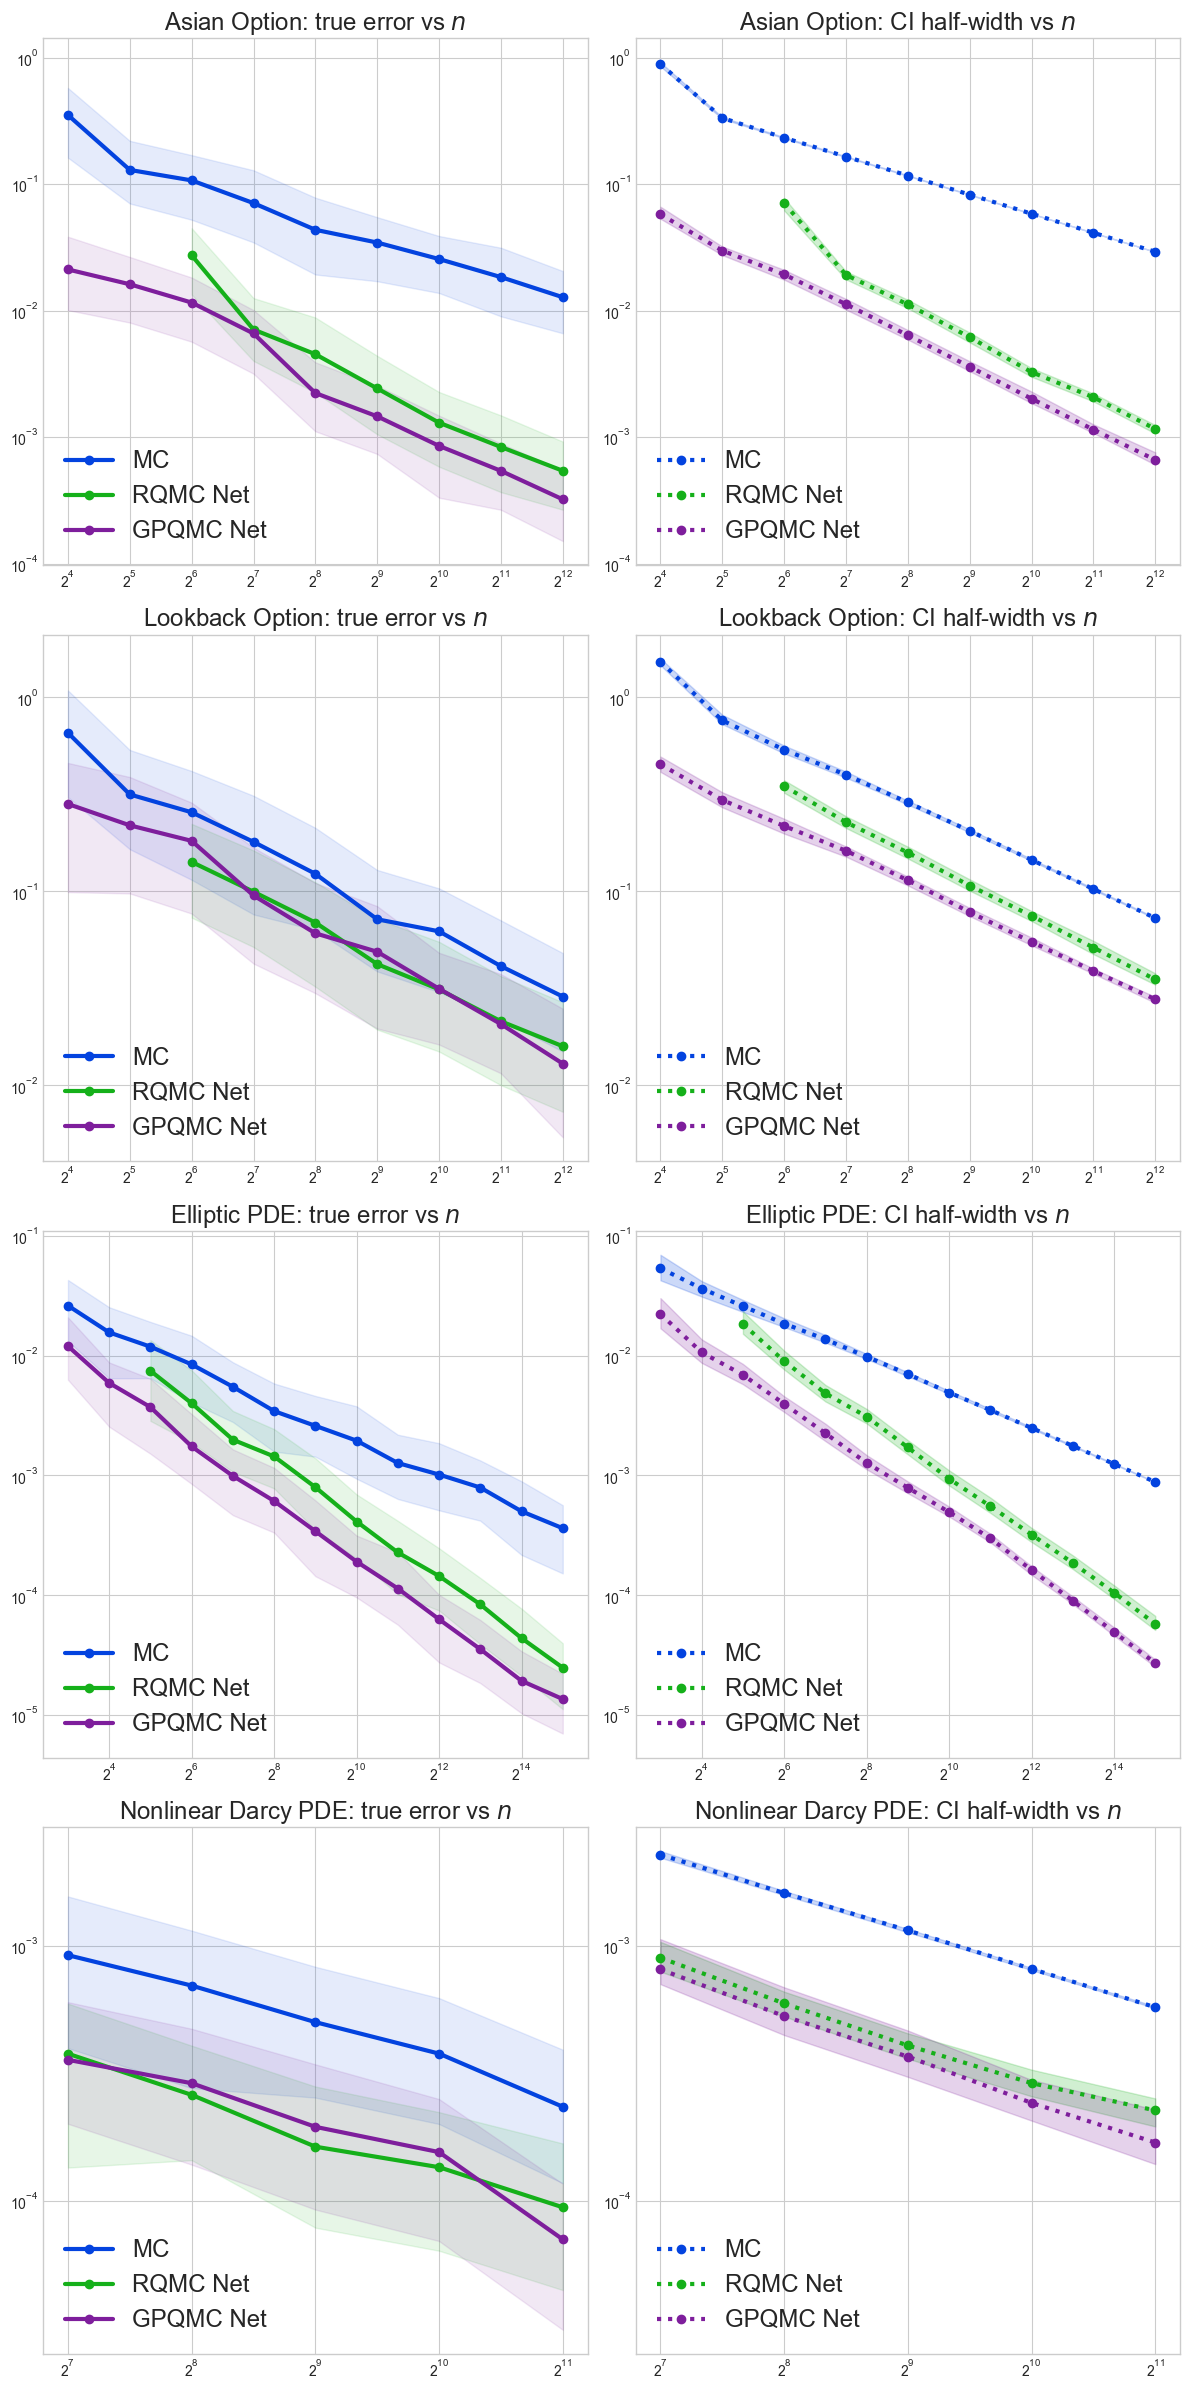

In [20]:
nrows = len(problem_names)
ncols = 2 
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(6*ncols,6*nrows),sharey="row",sharex="row")
ax = np.atleast_1d(ax).reshape(nrows,ncols)
for r in range(nrows):
    for i in range(len(names)):
        for j,(vals,linestyle,alpha) in enumerate(zip([true_errors[r][i],ci_half_widths[r][i]],[None,'dotted'],[.1,.2])):
            q_low = np.nanquantile(vals,.25,axis=1)
            q_med = np.nanquantile(vals,.5,axis=1)
            # q_med = np.mean(vals,axis=1)
            q_high = np.nanquantile(vals,.75,axis=1)
            label = names[i] #if r==j==0 else None
            ax[r,j].plot(max_budgets[r],q_med,marker='o',linestyle=linestyle,label=label,linewidth=LW,alpha=1,color=COLORS[i])
            ax[r,j].fill_between(max_budgets[r],q_low,q_high,alpha=alpha,color=COLORS[i])
            ax[r,j].legend(frameon=False,fontsize="xx-large",loc="lower left")
    ax[r,0].set_title(r"%s: true error vs $n$"%problem_names[r],fontsize="xx-large")
    ax[r,1].set_title(r"%s: CI half-width vs $n$"%problem_names[r],fontsize="xx-large")
    for j in range(2):
        ax[r,j].set_yscale("log",base=10)
        ax[r,j].set_xscale("log",base=2)
        ax[r,j].tick_params(labelleft=True,labelbottom=True)
# fig.suptitle(r"Error vs budget $n$",fontsize="xx-large")
# fig.legend(frameon=False,fontsize="x-large",bbox_to_anchor=(.9,.95),ncols=5)
fig.tight_layout()
figpath = dataroot+"convergence_by_error.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Convergence by Method

/Users/agsorok/miniconda3/envs/mlqmcpy/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.convergence_by_method.pdf


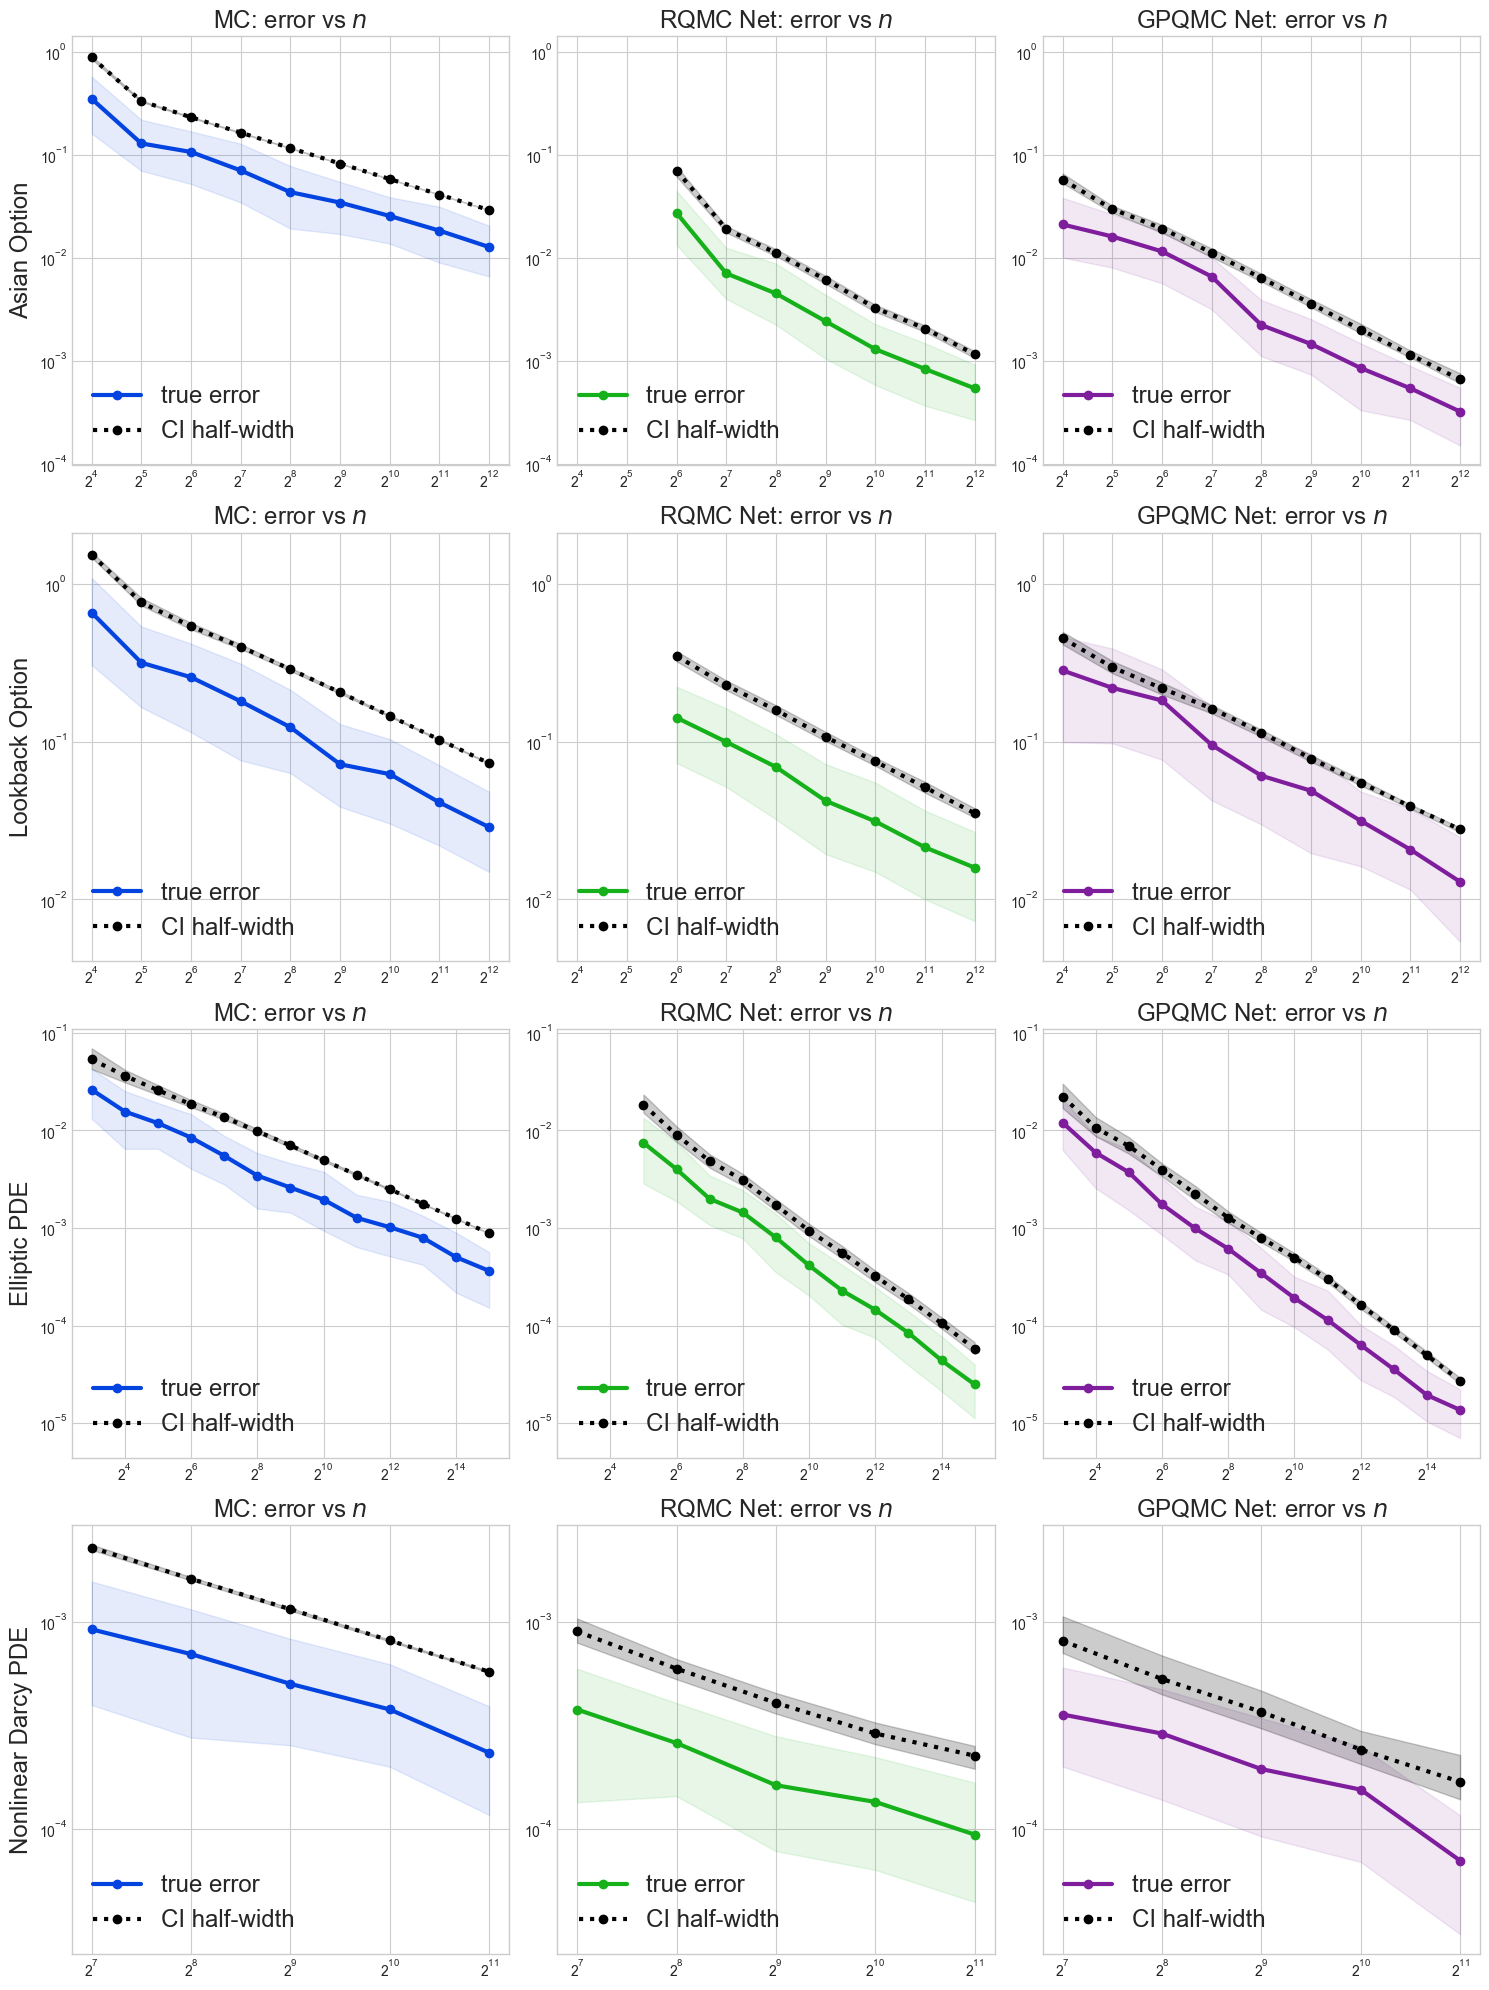

In [21]:
ncols = len(names)
nrows = len(problem_names)
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,5*nrows),sharey="row",sharex="row")
ax = np.atleast_1d(ax).reshape((nrows,ncols))
for r in range(nrows):
    for i in range(ncols):
        for j,(error_metric,vals,linestyle,alpha,color) in enumerate(zip(["true error","CI half-width"],[true_errors[r][i],ci_half_widths[r][i]],[None,'dotted'],[.1,.2],[COLORS[i],'k'])):
            q_low = np.nanquantile(vals,.25,axis=1)
            q_med = np.nanquantile(vals,.5,axis=1)
            # q_med = np.mean(vals,axis=1)
            q_high = np.nanquantile(vals,.75,axis=1)
            ax[r,i].plot(max_budgets[r],q_med,marker='o',linestyle=linestyle,label=error_metric,linewidth=LW,alpha=1,color=color)
            ax[r,i].fill_between(max_budgets[r],q_low,q_high,alpha=alpha,color=color)
            ax[r,i].set_title(r"%s: error vs $n$"%names[i],fontsize="xx-large")
            ax[r,i].legend(frameon=False,fontsize="xx-large",loc="lower left")
            ax[r,i].tick_params(labelleft=True,labelbottom=True)
        ax[r,i].set_yscale("log",base=10)
        ax[r,i].set_xscale("log",base=2)
    ax[r,0].set_ylabel(problem_names[r],fontsize="xx-large")
fig.tight_layout()
# fig.suptitle(r"Error vs budget $n$",fontsize="xx-large")
figpath = dataroot+"convergence_by_method.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Convergence

./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.convergence.pdf


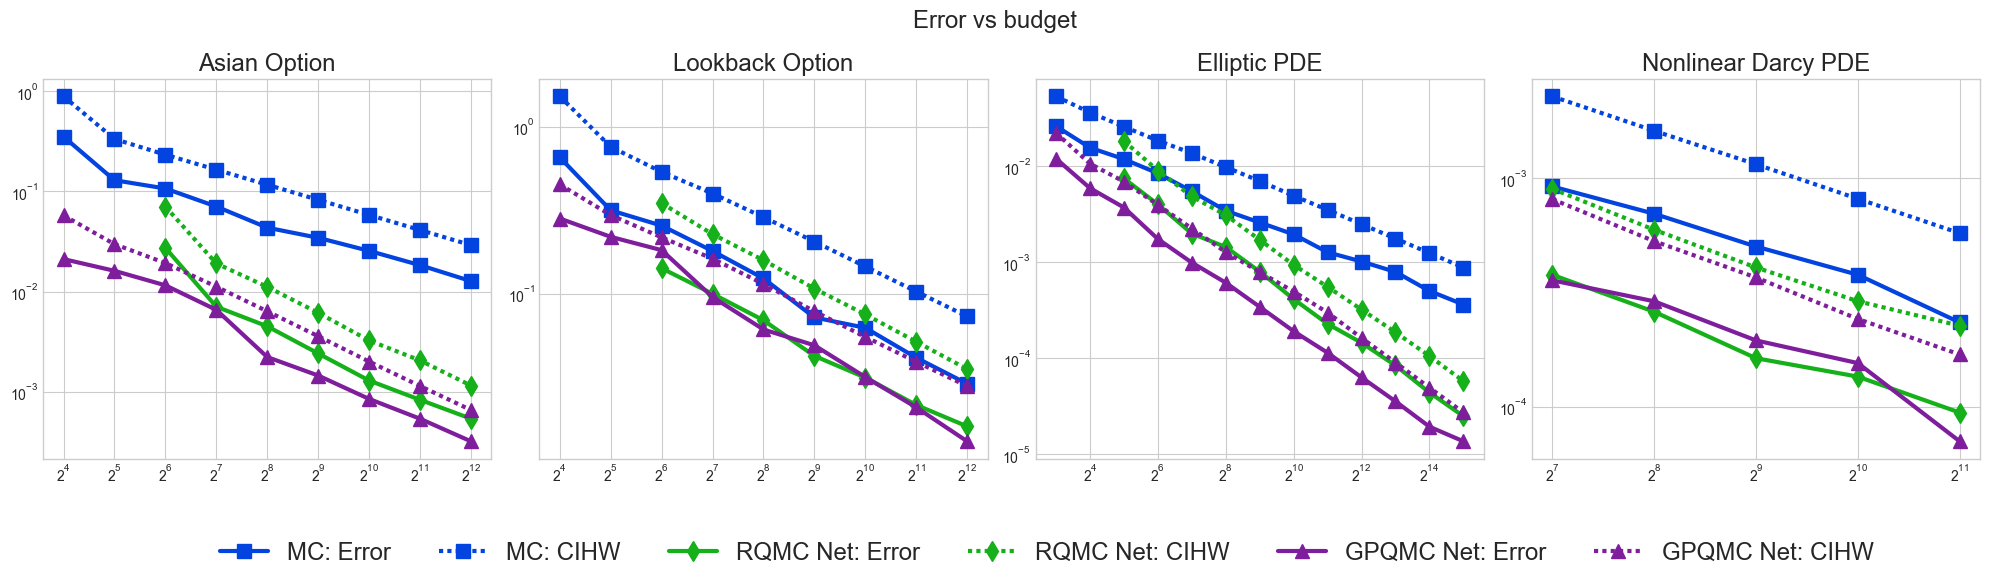

In [22]:
ncols = 4
nrows = int(np.ceil(len(problem_names)/ncols))
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,5*nrows))#,sharey="row",sharex="row")
ax = np.atleast_1d(ax).reshape((nrows,ncols))
for k in range(len(problem_names)):
    r,i = k//ncols,k%ncols 
    for j in range(len(names)):
        _te = true_errors[k][j]
        _cihw = ci_half_widths[k][j]
        _mean_te = np.median(_te,axis=1)
        _mean_cihw = np.median(_cihw,axis=1)
        _label_te = "%s: Error"%names[j] if r==i==0 else None
        _label_cihw = "%s: CIHW"%names[j] if r==i==0 else None
        ax[r,i].plot(max_budgets[k],_mean_te,marker=MARKERS[j],markersize=10,linestyle=LINESTYLES[0],label=_label_te,linewidth=LW,alpha=1,color=COLORS[j])
        ax[r,i].plot(max_budgets[k],_mean_cihw,marker=MARKERS[j],markersize=10,linestyle=LINESTYLES[-1],label=_label_cihw,linewidth=LW,alpha=1,color=COLORS[j])
    ax[r,i].set_title(problem_names[k],fontsize="xx-large")
    ax[r,i].tick_params(labelleft=True,labelbottom=True)
    ax[r,i].set_yscale("log",base=10)
    ax[r,i].set_xscale("log",base=2)
fig.legend(frameon=False,fontsize='xx-large',bbox_to_anchor=(.95,-.04),ncols=6)
fig.suptitle(r"Error vs budget",fontsize="xx-large")
fig.tight_layout()
figpath = dataroot+"convergence.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Error Scatters

./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.error_scatters.pdf


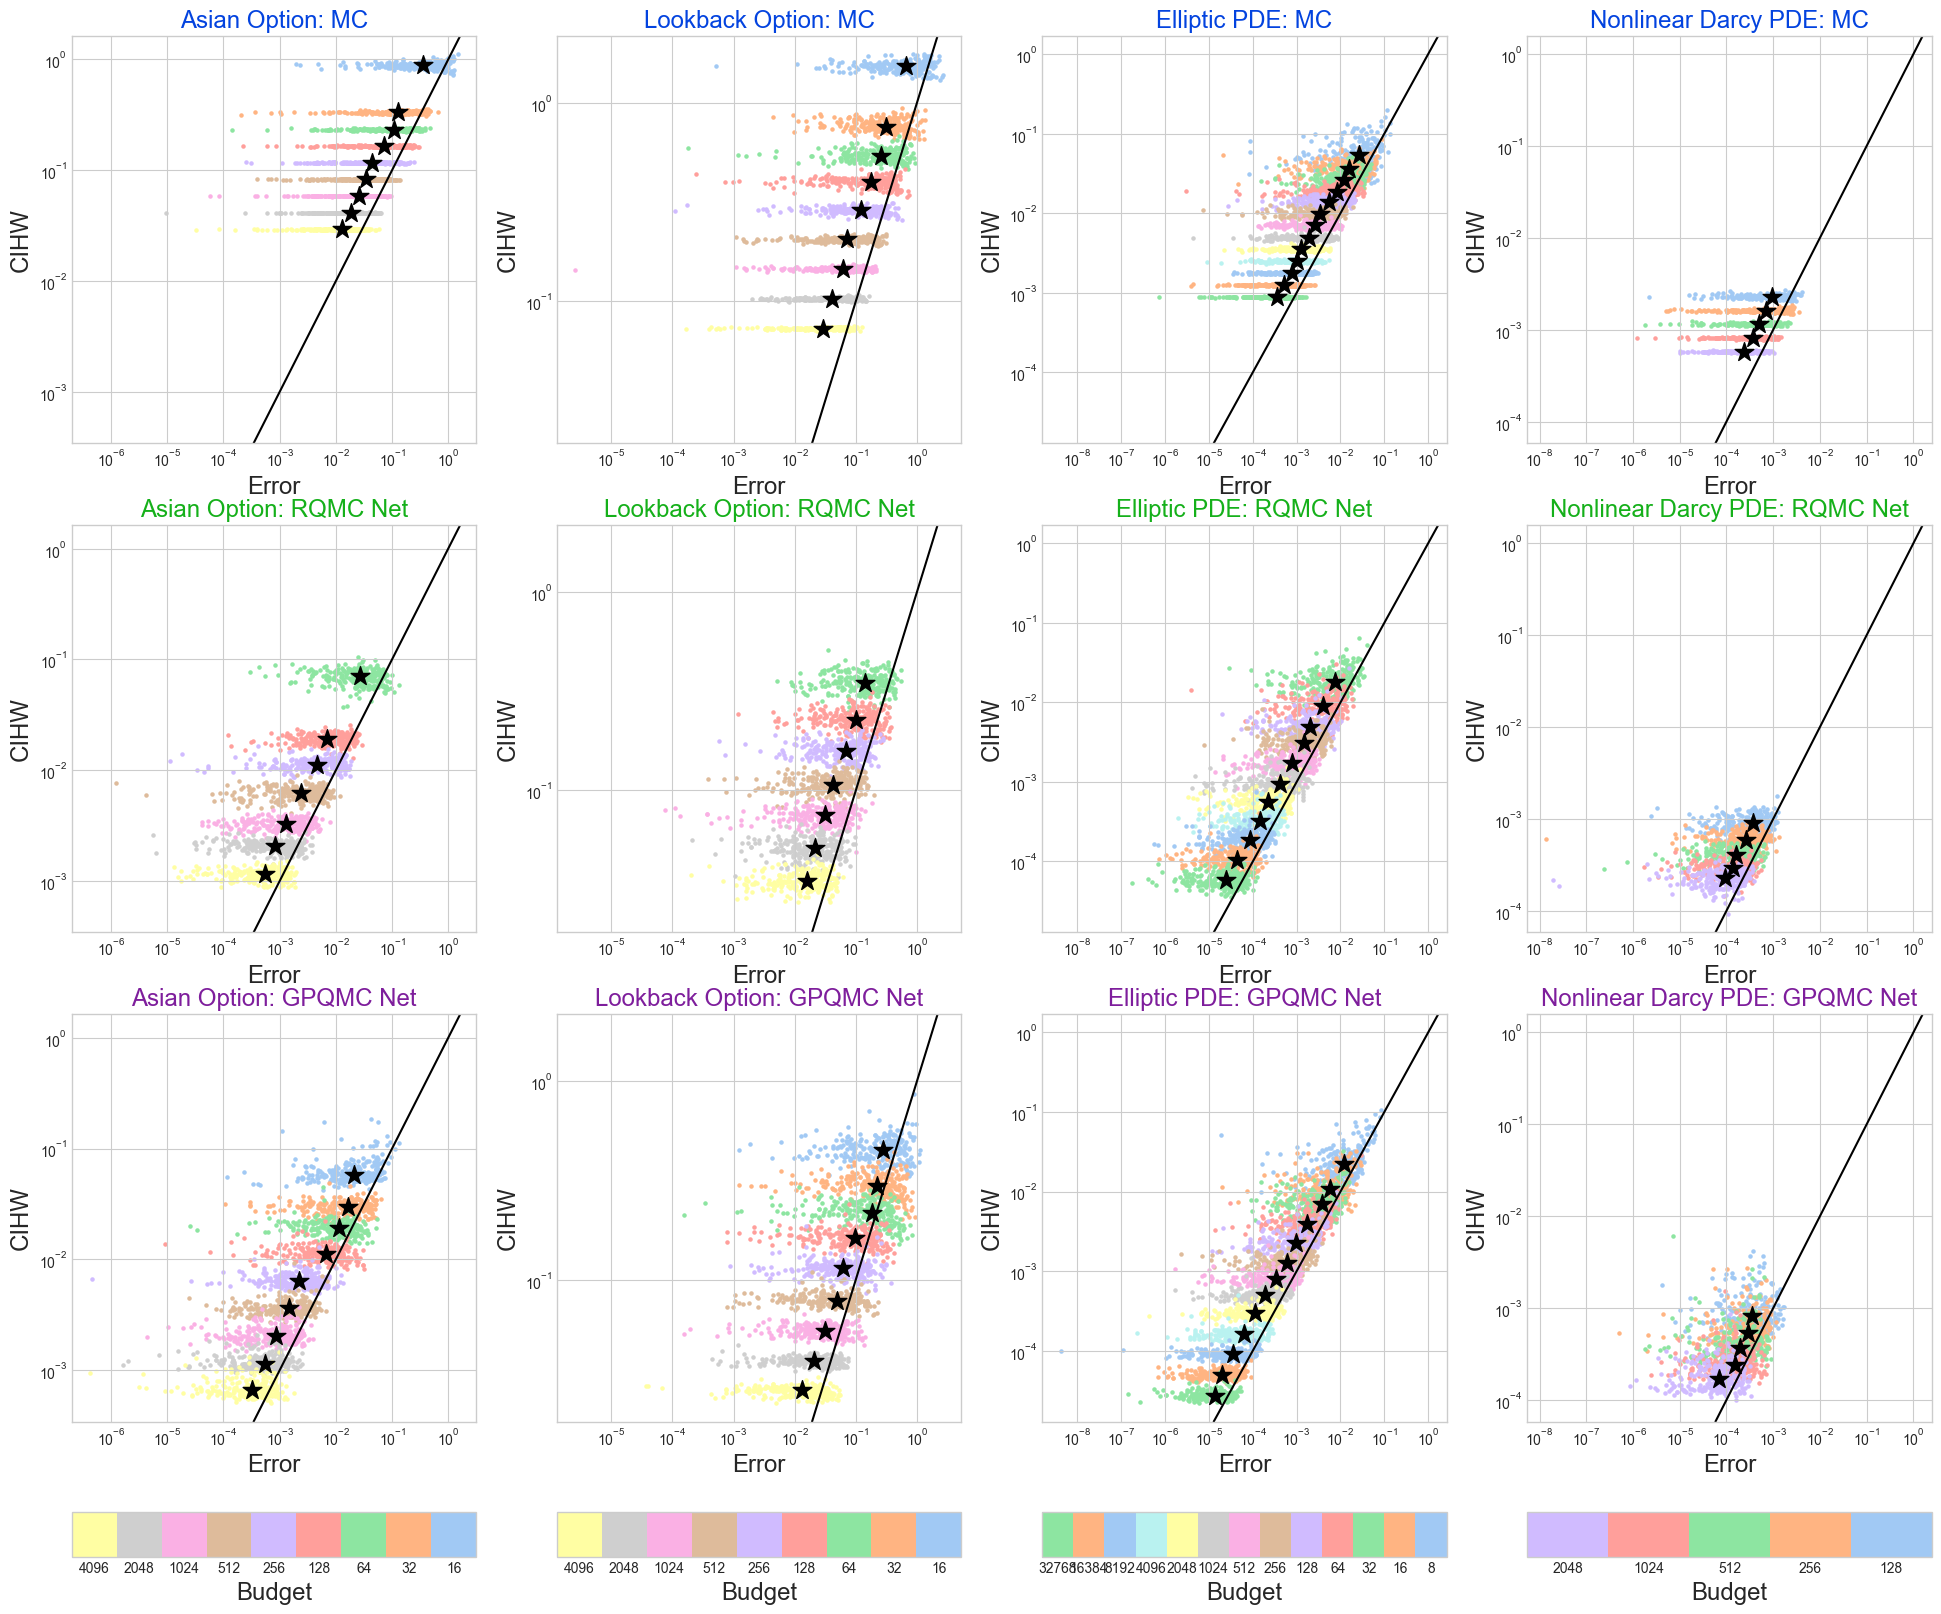

In [23]:
nrows = len(names)
ncols = len(problem_names)
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(6*ncols,6*nrows),sharex="col",sharey="col")
ax = np.atleast_1d(ax).reshape((nrows,ncols))
for j in range(ncols):
    cmapcolors = sns.color_palette("pastel",n_colors=len(max_budgets[j])) # https://seaborn.pydata.org/tutorial/color_palettes.html
    cmap = matplotlib.colors.ListedColormap(cmapcolors)
    norm = matplotlib.colors.BoundaryNorm(np.arange(cmap.N+1)+1/2,cmap.N)
    for i in range(nrows):
        for k in range(len(max_budgets[j])):
            ax[i,j].scatter(true_errors[j][i,k],ci_half_widths[j][i,k],label=name,color=cmapcolors[k],zorder=0,s=5)
            ax[i,j].scatter(np.median(true_errors[j][i,k]),np.median(ci_half_widths[j][i,k]),color='k',s=200,marker='*')#,alpha=.25)
            # ax[i,j].scatter(np.mean(true_errors[j][i,k]),np.mean(ci_half_widths[j][i,k]),color='k',s=200,marker='*')
        ax[i,j].axline(xy1=(0,0),xy2=(1,1),color="k")
        ax[i,j].tick_params(labelbottom=True,labelleft=True)
        ax[i,j].set_xscale("log",base=10)
        ax[i,j].set_yscale("log",base=10)
        ax[i,j].set_xlabel("Error",fontsize="xx-large")
        ax[i,j].set_ylabel("CIHW",fontsize="xx-large")
        ax[i,j].set_title(r"%s: %s"%(problem_names[j],names[i]),fontsize="xx-large",color=COLORS[i])
    cax = fig.add_axes([ax[-1,j].get_position().x0,ax[-1,j].get_position().y0-.075,ax[-1,j].get_position().x1-ax[-1,j].get_position().x0,0.025])
    cbar = fig.colorbar(matplotlib.cm.ScalarMappable(cmap=cmap,norm=norm),cax=cax,location="bottom")
    cbar.ax.set_xlabel("Budget",fontsize="xx-large")
    cbar.set_ticks(np.arange(1,len(max_budgets[j])+1))
    cbar.set_ticklabels(max_budgets[j])
    cbar.ax.invert_xaxis()
# fig.suptitle("true error vs CI half-width",fontsize='xx-large')
# fig.tight_layout()
figpath = dataroot+"error_scatters.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Coverage Bars 

./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.coverage_bars.pdf


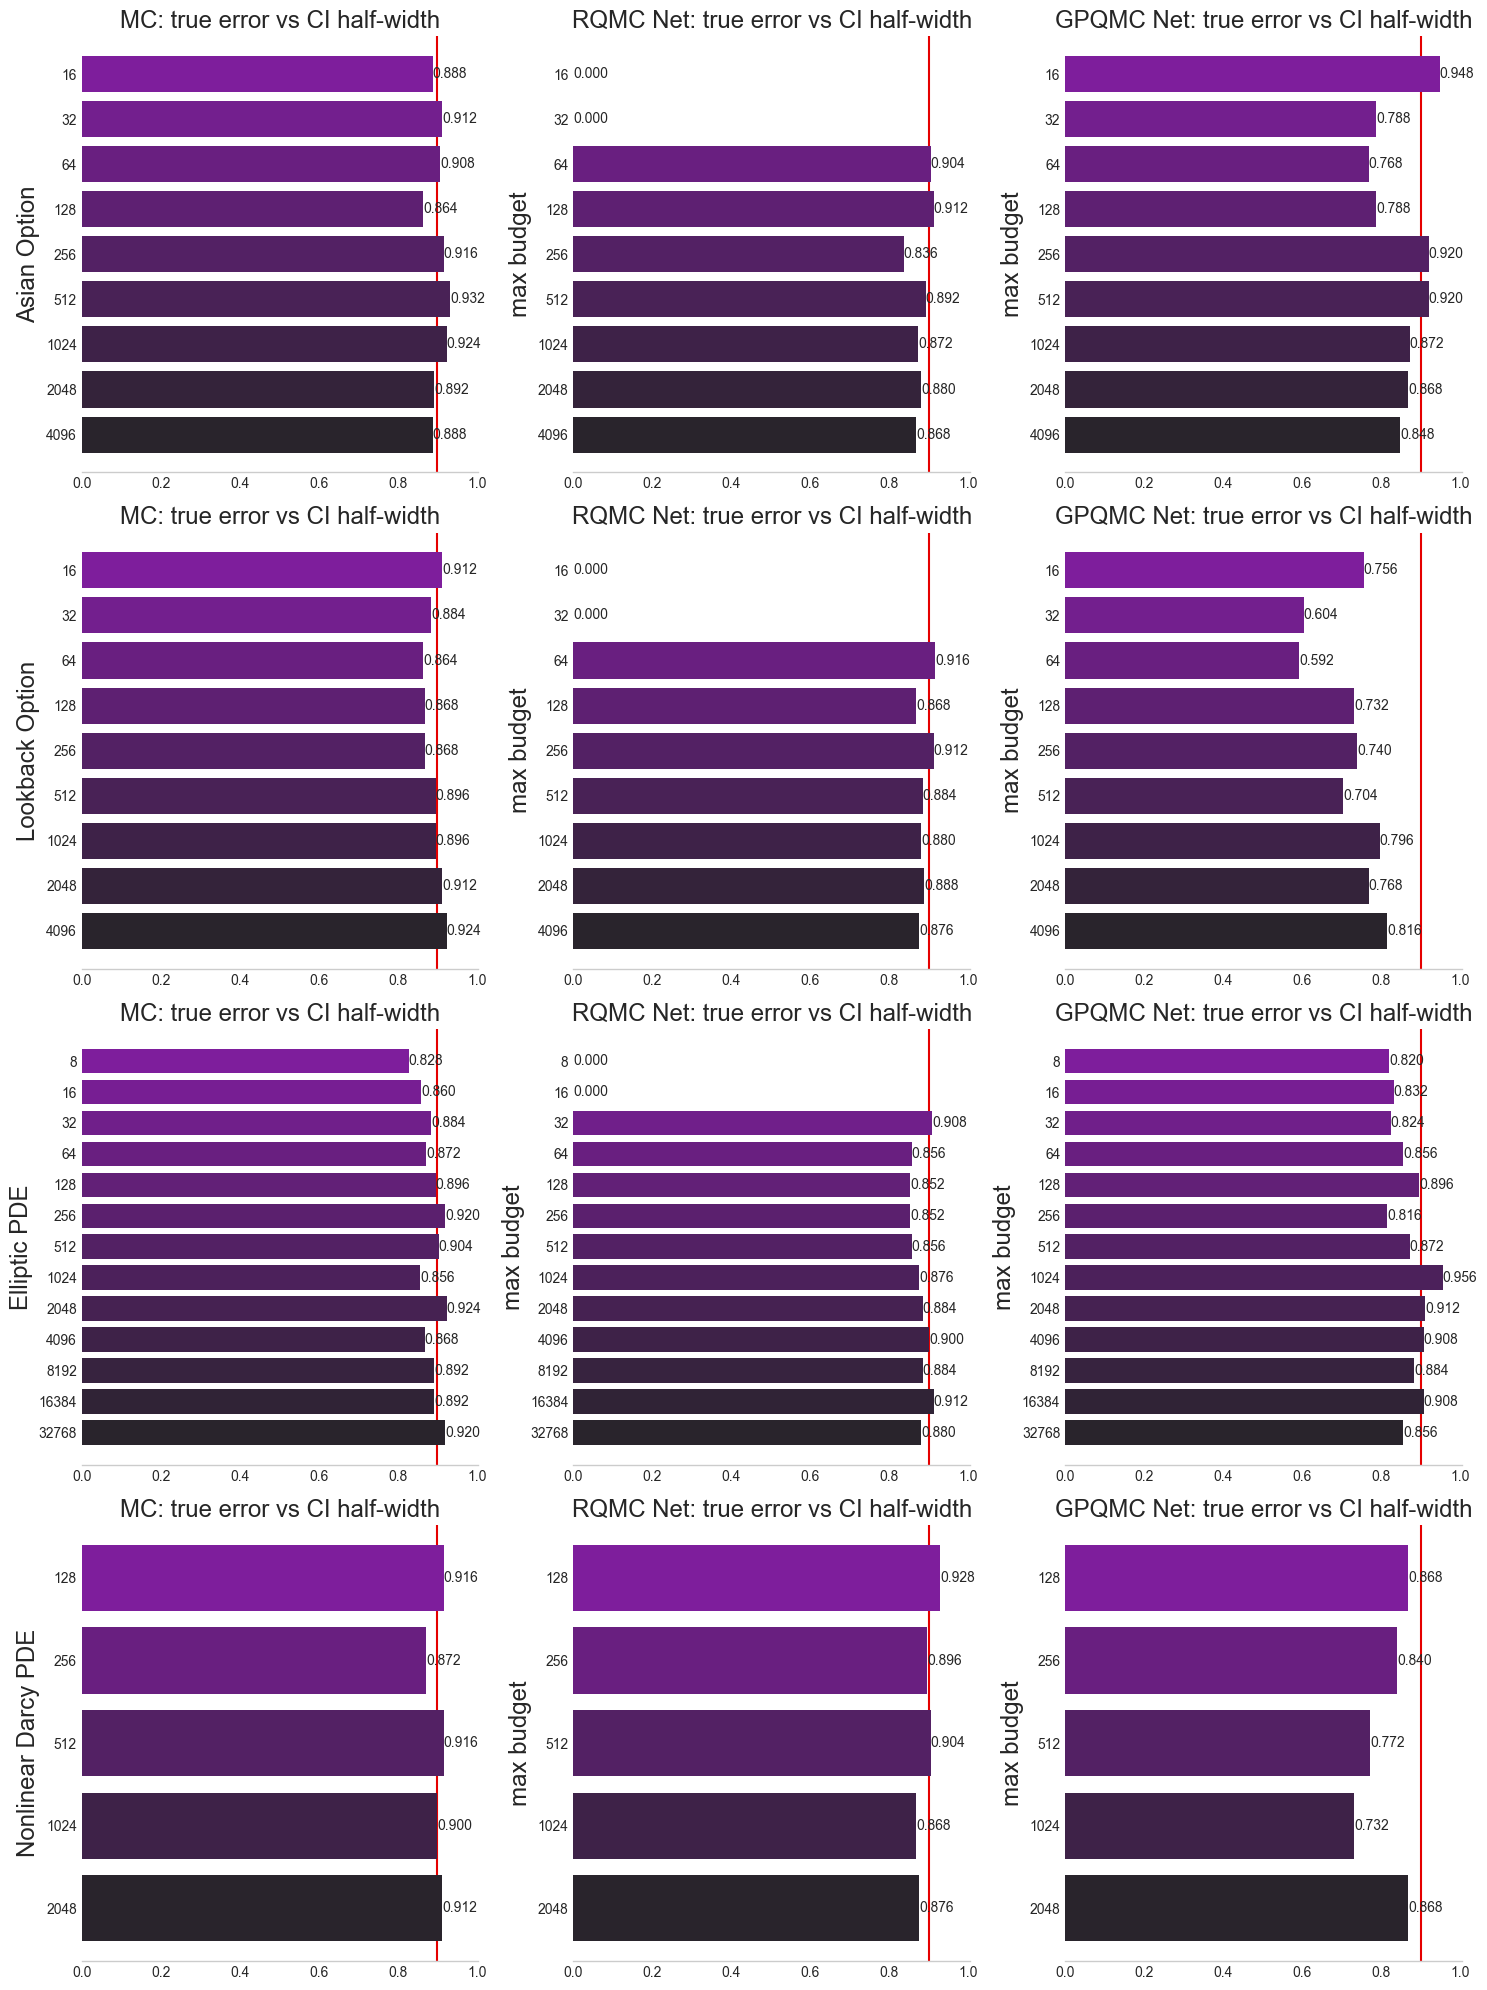

In [24]:
nrows = len(problem_names)
ncols = len(names)
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,5*nrows),sharex=True,sharey="row")
ax = np.atleast_1d(ax).reshape((nrows,ncols))
for i in range(nrows):
    for j in range(ncols):
        ax[i,j].axvline(x=ALPHA,color="xkcd:red")
        palette = sns.dark_palette("xkcd:purple",n_colors=len(max_budgets[i]),reverse=True) # https://seaborn.pydata.org/generated/seaborn.cubehelix_palette.html
        for k in range(len(max_budgets[i])):
            coverage = np.mean(true_errors[i][j,k]<ci_half_widths[i][j,k])
            bar = ax[i,j].barh(len(max_budgets[i])-k-1,coverage,label=name,color=palette[k],zorder=10)
            ax[i,j].bar_label(bar, fmt='%.3f')
        for spine in ["top","right","left"]: ax[i,j].spines[spine].set_visible(False)
        ax[i,j].grid(False)
        ax[i,j].tick_params(labelbottom=True,labelleft=True)
        ax[i,j].set_ylabel("max budget",fontsize="xx-large")
        ax[i,j].set_yticks(np.arange(len(max_budgets[i])))
        ax[i,j].set_yticklabels(max_budgets[i][::-1])
        ax[i,j].set_title("%s: true error vs CI half-width"%names[j],fontsize="xx-large")
    ax[i,0].set_ylabel(problem_names[i],fontsize="xx-large")
# fig.suptitle("true error vs CI half-width",fontsize='xx-large')
fig.tight_layout()
figpath = dataroot+"coverage_bars.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Densities

./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.densities.pdf


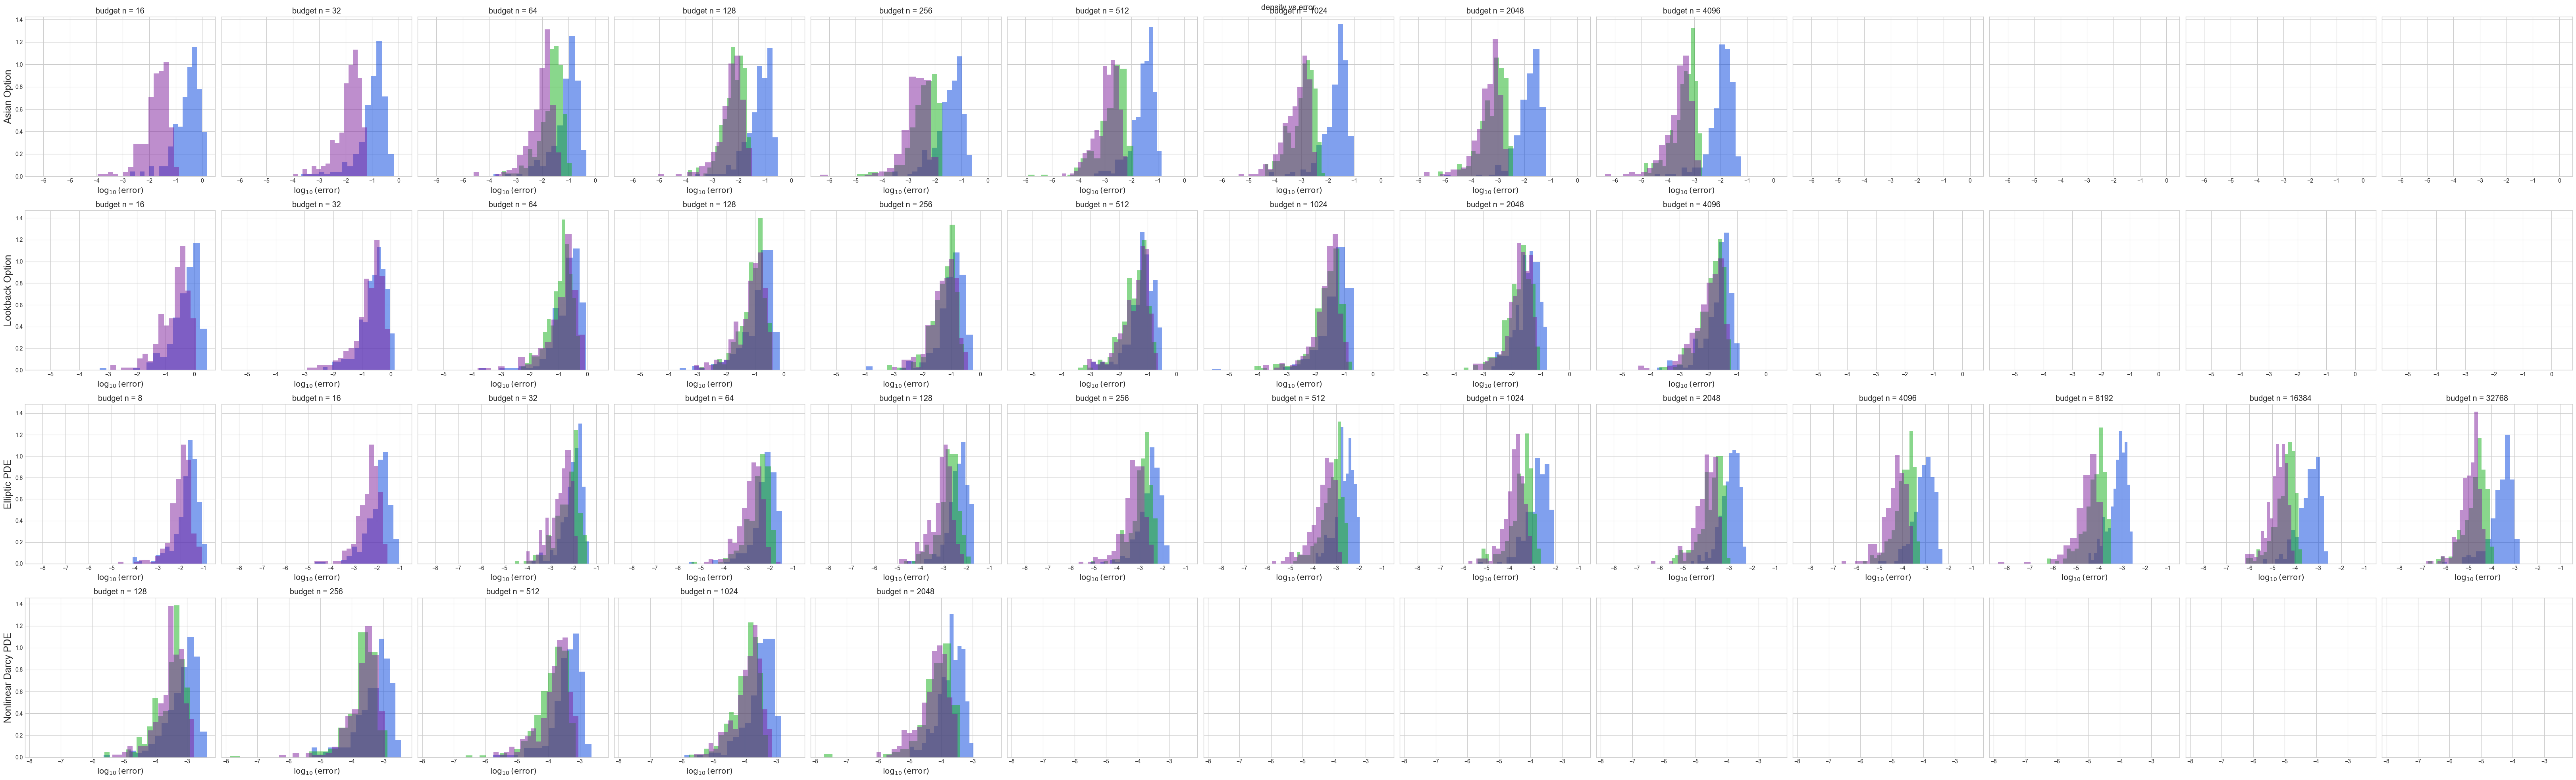

In [28]:
nrows = len(problem_names)
ncols = max([len(max_budgets[i]) for i in range(len(max_budgets))])
EPS = np.finfo(true_errors[0].dtype).eps
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(ncols*5,nrows*5),sharex="row",sharey="row")
ax = np.atleast_1d(ax).reshape(nrows,ncols)
for i in range(nrows):
    for j in range(len(max_budgets[i])):
        for k in range(len(names)):
            vals = true_errors[i][k,j]
            if np.isnan(vals).all(): continue
            ax[i,j].hist(np.log10(np.maximum(EPS,vals)),label=name,density=True,bins=16,alpha=.5,color=COLORS[k]) 
        ax[i,j].set_title(r"budget n = %d"%max_budgets[i][j],fontsize="x-large")
        ax[i,j].set_xlabel(r"$\log_{10}(\mathrm{error})$",fontsize="x-large")
    ax[i,0].set_ylabel(problem_names[i],fontsize="xx-large")
fig.suptitle(r"density vs error",fontsize="x-large")
fig.tight_layout()
figpath = dataroot+"densities.pdf"
print(dataroot+"densities.pdf")
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Sample Allocation Grouped by Budget

./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.sample_allocation_group_budget.pdf


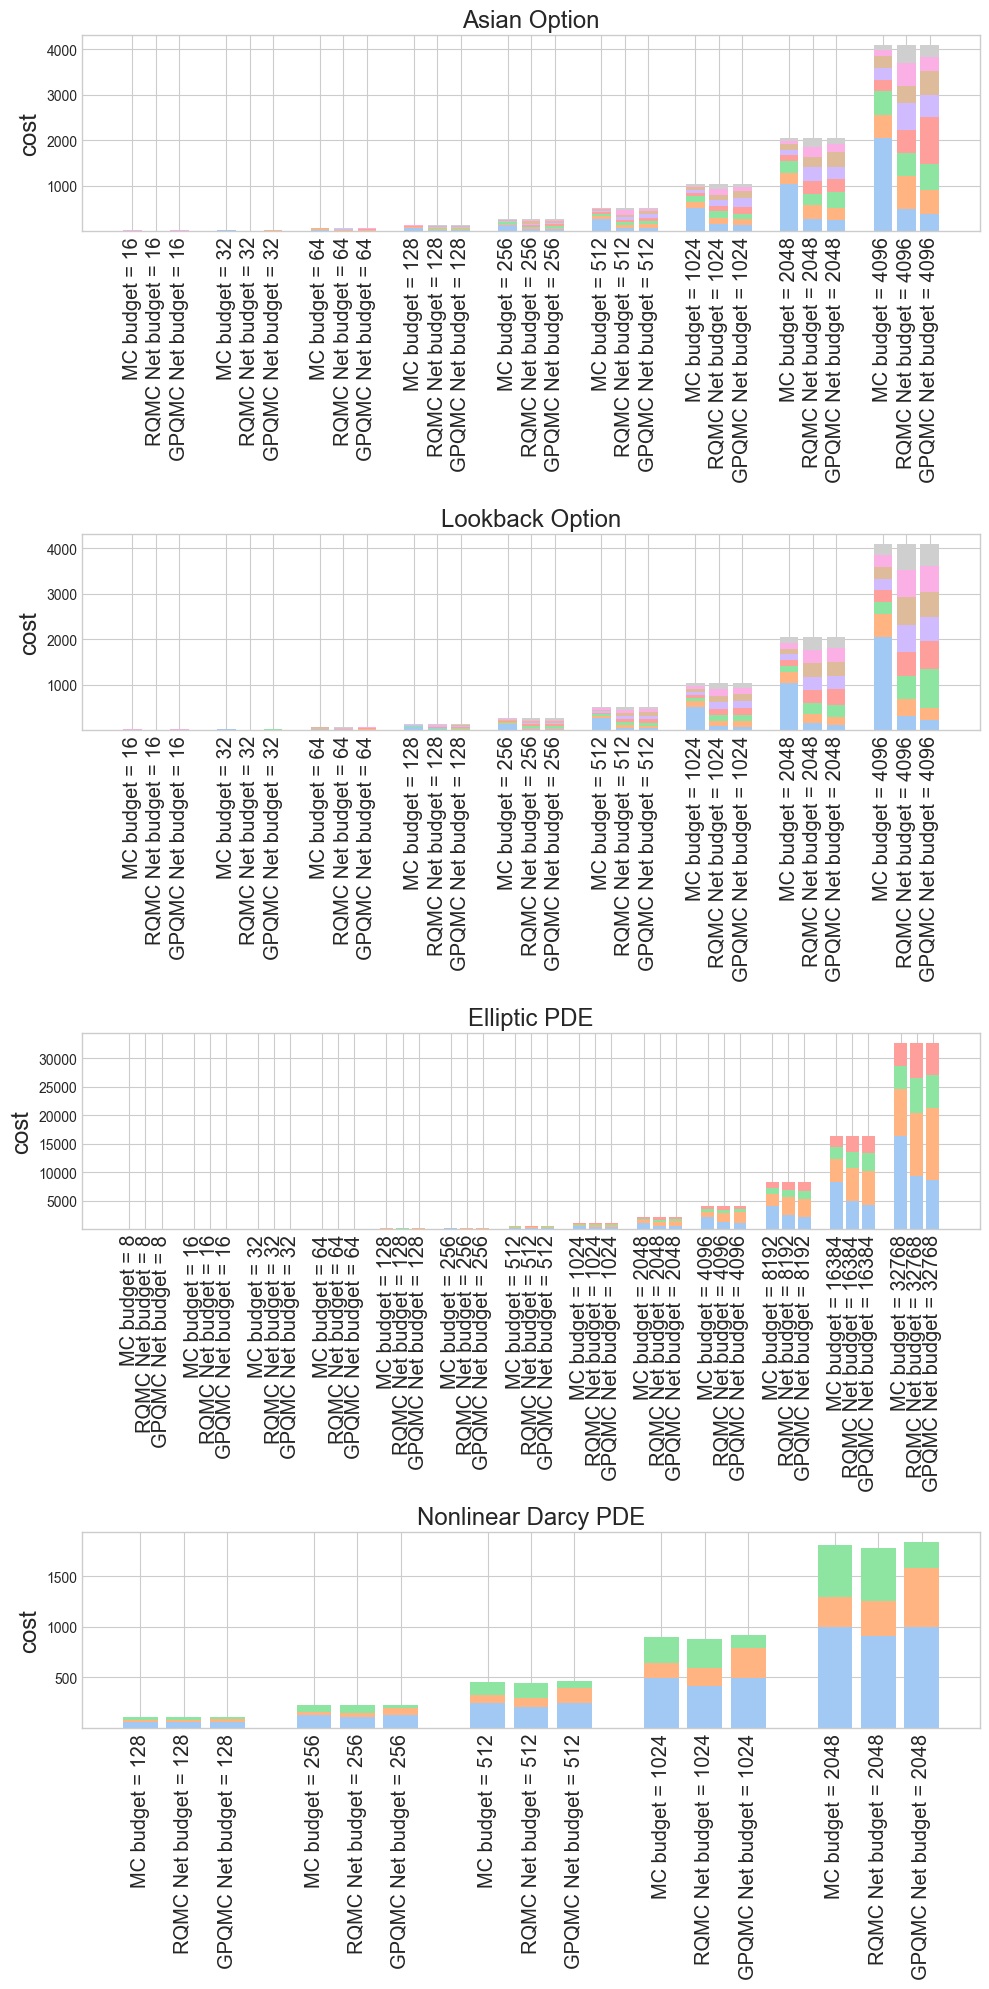

In [26]:
nrows = len(problem_names)
fig,ax = pyplot.subplots(nrows=nrows,ncols=1,figsize=(10,5*nrows))
ax = np.atleast_1d(ax).reshape(nrows)
for i in range(nrows):
    s = 0
    palette = sns.color_palette("pastel",n_colors=num_levels[i]) # https://seaborn.pydata.org/tutorial/color_palettes.html
    allticks = []
    allticklabels = []
    for j in range(len(max_budgets[i])):
        bottom = 0
        ticks = s+np.arange(len(names))
        allticks.append(ticks)
        allticklabels += [names[t]+" budget = %d"%max_budgets[i][j] for t in range(len(names))]
        for k in range(num_levels[i]):
            costs = np.mean(samples_per_level[i][:,j,...,k]*costs_per_level[i][k],axis=-1)
            bars = ax[i].bar(ticks,costs,bottom=bottom,color=palette[k])
            # ax[i].bar_label(bars,label_type='center')
            bottom += costs
        s += len(names)+1
    _ylow,_y_high = ax[i].get_ylim()
    ax[i].set_ylim([1,_y_high])
    # ax[i].set_yscale("log",base=2)
    # ax[i].set_yticks([])
    ax[i].set_ylabel("cost",fontsize="xx-large")
    ax[i].set_xticks(np.hstack(allticks))
    ax[i].set_xticklabels(allticklabels,fontsize="x-large",rotation=90)
    ax[i].set_title(problem_names[i],fontsize="xx-large")
fig.tight_layout()
figpath = dataroot+"sample_allocation_group_budget.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")


## Sample Allocation Grouped by Level

./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.sample_allocation_group_level.pdf


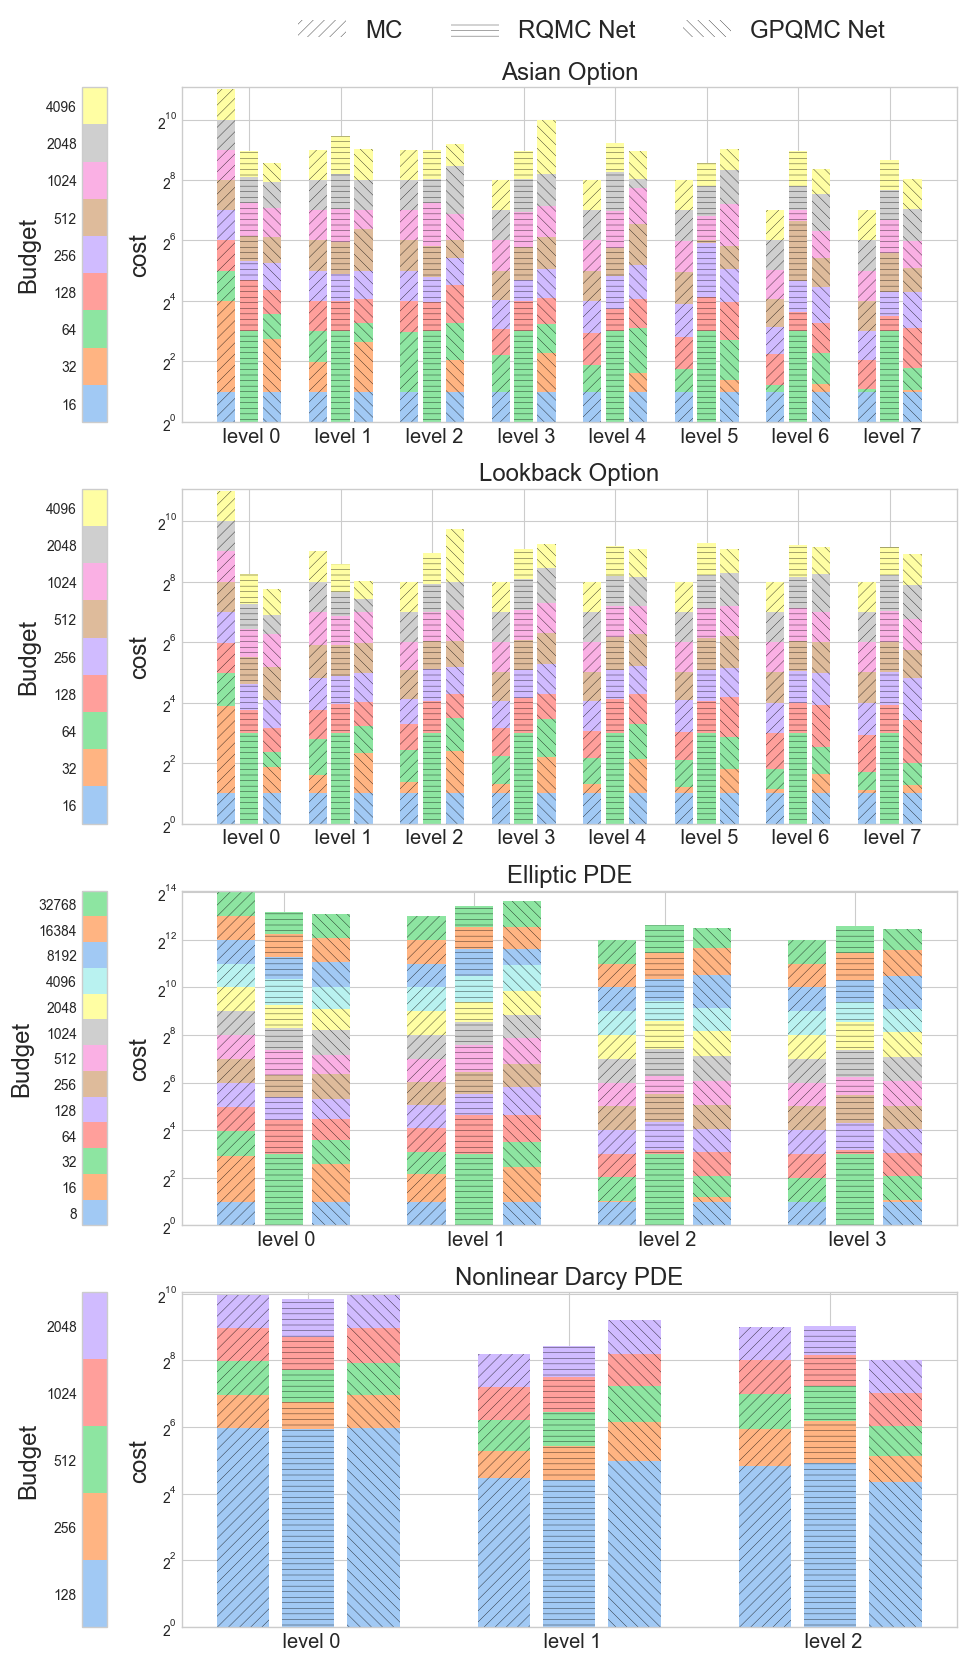

In [27]:
matplotlib.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
hatches = ['///','---','\\\\\\','/','-','\\']
nrows = len(problem_names)
fig,ax = pyplot.subplots(nrows=nrows,ncols=1,figsize=(10,5*nrows))
ax = np.atleast_1d(ax).reshape(nrows)
for i in range(nrows):
    s = 0
    cmapcolors = sns.color_palette("pastel",n_colors=len(max_budgets[i])) # https://seaborn.pydata.org/tutorial/color_palettes.html
    cmap = matplotlib.colors.ListedColormap(cmapcolors)
    norm = matplotlib.colors.BoundaryNorm(np.arange(cmap.N+1)+1/2,cmap.N)
    allticks = []
    allticklabels = []
    for j in range(num_levels[i]):
        bottom = 0
        ticks = s+np.arange(len(names))
        # allticks.append(ticks)
        allticks.append(ticks.mean())
        # allticklabels += [names[t]+" level = %d"%j for t in range(len(names))]
        allticklabels += [" level %d"%j]
        # allticklabels += [" level %d\nCPS %.1e"%(j,costs_per_level[i][j])]
        for k in range(len(max_budgets[i])):
            costs = np.mean(samples_per_level[i][:,k,...,j]*costs_per_level[i][j],axis=-1)
            costs[np.isnan(costs)] = 0
            costs_diff = np.maximum(costs,bottom)-bottom
            bars = ax[i].bar(ticks,costs_diff,bottom=bottom,color=cmapcolors[k])
            # ax[i].bar_label(bars,label_type='center')
            bottom += costs_diff
        for ii in range(len(names)):
            # ax[i].bar(ticks[ii],bottom[ii],facecolor='none',edgecolor=COLORS[ii],linewidth=3,label=names[ii] if i==j==0 else None)
            ax[i].bar(ticks[ii],bottom[ii],hatch=hatches[ii],facecolor='none',label=names[ii] if i==j==0 else None)
        s += len(names)+1
    _ylow,_y_high = ax[i].get_ylim()
    ax[i].set_ylim([1,_y_high])
    ax[i].set_yscale("log",base=2)
    # ax[i].set_yticks([])
    ax[i].set_ylabel("cost",fontsize="xx-large")
    ax[i].set_xticks(np.hstack(allticks))
    ax[i].set_xticklabels(allticklabels,fontsize="x-large")
    ax[i].set_title(problem_names[i],fontsize="xx-large")
    cax = fig.add_axes([ax[i].get_position().x0-.1,ax[i].get_position().y0,0.025,ax[i].get_position().y1-ax[i].get_position().y0])
    cbar = fig.colorbar(matplotlib.cm.ScalarMappable(cmap=cmap,norm=norm),cax=cax,location="left")
    cbar.ax.set_ylabel("Budget",fontsize="xx-large")
    cbar.set_ticks(np.arange(1,len(max_budgets[i])+1))
    cbar.set_ticklabels(max_budgets[i])
fig.legend(frameon=False,ncols=3,bbox_to_anchor=(.85,.925),fontsize="xx-large")
# fig.tight_layout()
figpath = dataroot+"sample_allocation_group_level.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Sample Allocation

./budgeted_comparison_data/ML/OUT/dnet.ml/dnet.ml.sample_allocation_last.pdf


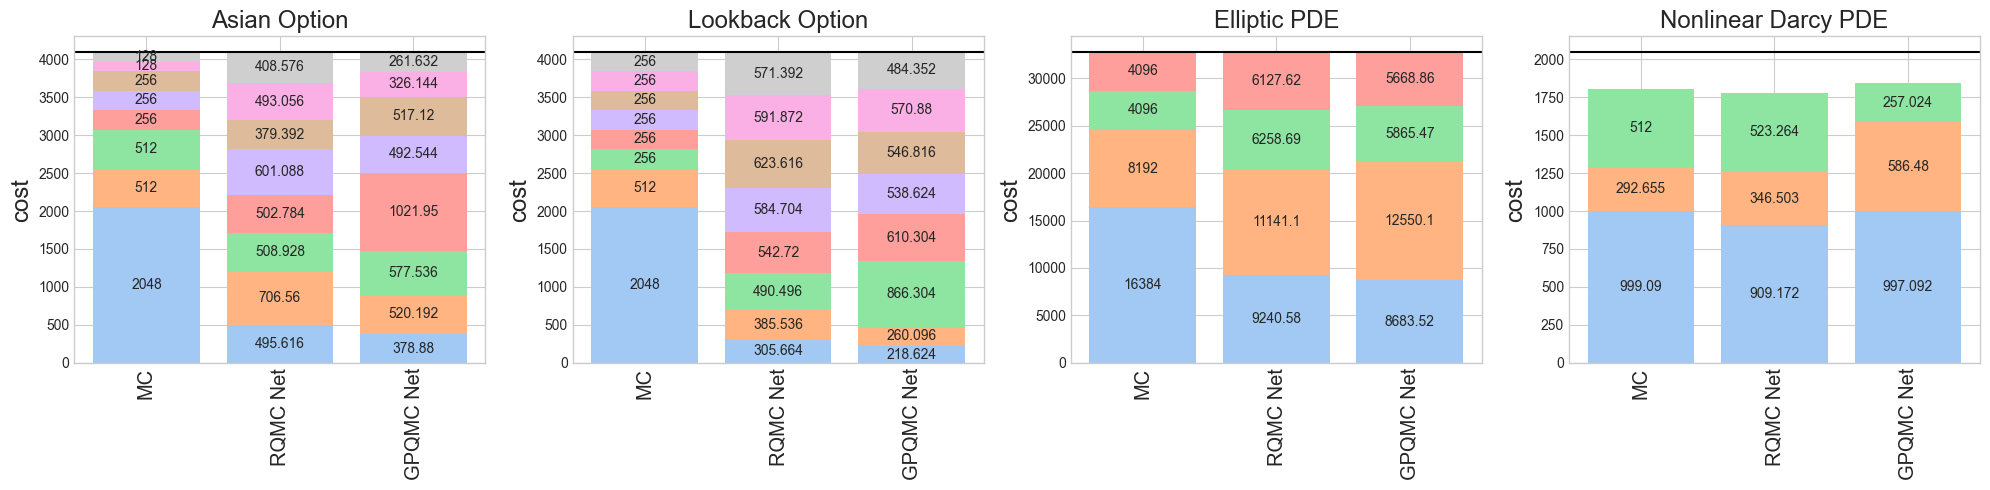

In [29]:
ncols = len(problem_names)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5),sharey=False)
ax = np.atleast_1d(ax).reshape(nrows)
for i in range(ncols):
    palette = sns.color_palette("pastel",n_colors=num_levels[i]) # https://seaborn.pydata.org/tutorial/color_palettes.html
    bottom = 0
    ticks = np.arange(len(names))
    for k in range(num_levels[i]):
        vals = samples_per_level[i][:,-1,...,k]*costs_per_level[i][k]
        costs = np.mean(vals,axis=-1)
        bars = ax[i].bar(ticks,costs,bottom=bottom,color=palette[k])
        ax[i].bar_label(bars,label_type='center')
        bottom += costs
    ax[i].axhline(max_budgets[i][-1],color="k")#,alpha=.25)
    ax[i].set_xticks(ticks)
    ax[i].set_xticklabels(names,fontsize="x-large",rotation=90)
    ax[i].set_title(problem_names[i],fontsize="xx-large")
    ax[i].set_ylabel("cost",fontsize="xx-large")
fig.tight_layout()
figpath = dataroot+"sample_allocation_last.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")
